# 多项式回归

想象一下，你正在观察一个物体从空中落下的轨迹，它下落的速度不是均匀的，而是越来越快。如果你用一条直线去拟合这个轨迹，效果会很差，因为直线无法描述这种弯曲的变化。这时，我们就需要一种能弯曲的线——多项式回归就是解决这类问题的强大工具。

简单来说，多项式回归是线性回归的一种扩展。它通过为原始特征添加高次项（如平方项、立方项），将数据映射到更高维度的空间，从而用一条"曲线"来拟合数据中存在的非线性关系。

## 核心概念：从直线到曲线

$$
y = w_1 * x + w_2 * x^2 + b
z
$$

可以把这个 x^2 替换为一个新的参数，又回到多元线性回归

## 用 Python 实现多项式回归

In [1]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 设置随机种子，确保每次运行结果一致
np.random.seed(42)

/tmp/ipykernel_55757/4043866747.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


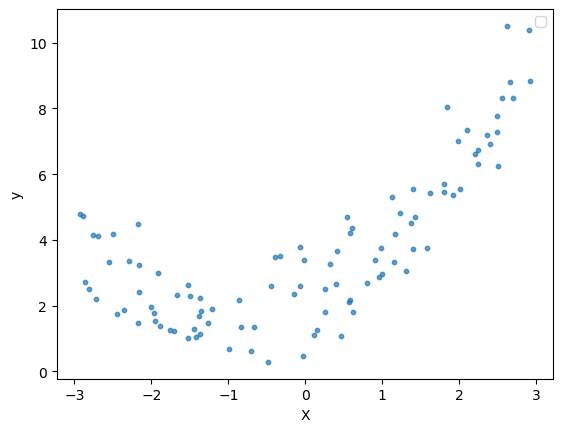

In [7]:
# 生成100个在[-3, 3)区间的随机数
X = 6 * np.random.rand(100, 1) - 3

y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)

plt.scatter(X, y, s=10, alpha=0.7)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

### 核心步骤：特征转换与模型训练

关键步骤是使用 PolynomialFeatures 来生成高次项特征。

In [13]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

print(f"原始X的形状: {X.shape}")
print(f"转换后X_poly的形状: {X_poly.shape}")
print(f"前5行X_poly数据:\n{X_poly[:5]}")
# 输出显示，X_poly 有两列：第一列是X，第二列是X^2

原始X的形状: (100, 1)
转换后X_poly的形状: (100, 2)
前5行X_poly数据:
[[ 1.58163476  2.50156853]
 [-2.15932095  4.66266695]
 [ 2.21080786  4.88767137]
 [-0.07541281  0.00568709]
 [ 2.36731336  5.60417255]]


In [9]:

# 2. 在转换后的特征上训练线性回归模型
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)  # 使用X_poly，而不是原始的X

# 3. 查看学到的模型参数（权重和偏置）
print(f"\n模型参数（权重w1, w2）: {lin_reg.coef_.ravel()}")
print(f"模型偏置（截距b）: {lin_reg.intercept_}")
# 输出结果应接近我们生成数据时用的参数 [1, 0.5] 和 2


模型参数（权重w1, w2）: [0.98988775 0.53173112]
模型偏置（截距b）: [2.11583754]


/tmp/ipykernel_55757/1729619273.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


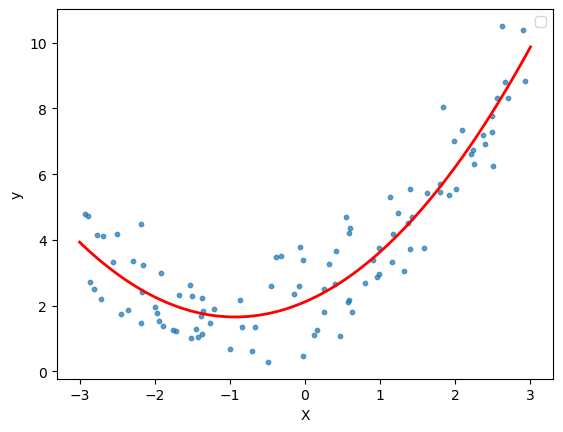

In [11]:
# 为了画出平滑的曲线，需要生成一组均匀分布的点
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
# 对这组新点同样进行多项式特征转换
X_new_poly = poly_features.transform(X_new)
# 用模型进行预测
y_new = lin_reg.predict(X_new_poly)

# 开始绘图
plt.scatter(X, y, s=10, alpha=0.7)
plt.plot(X_new, y_new, 'r-', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

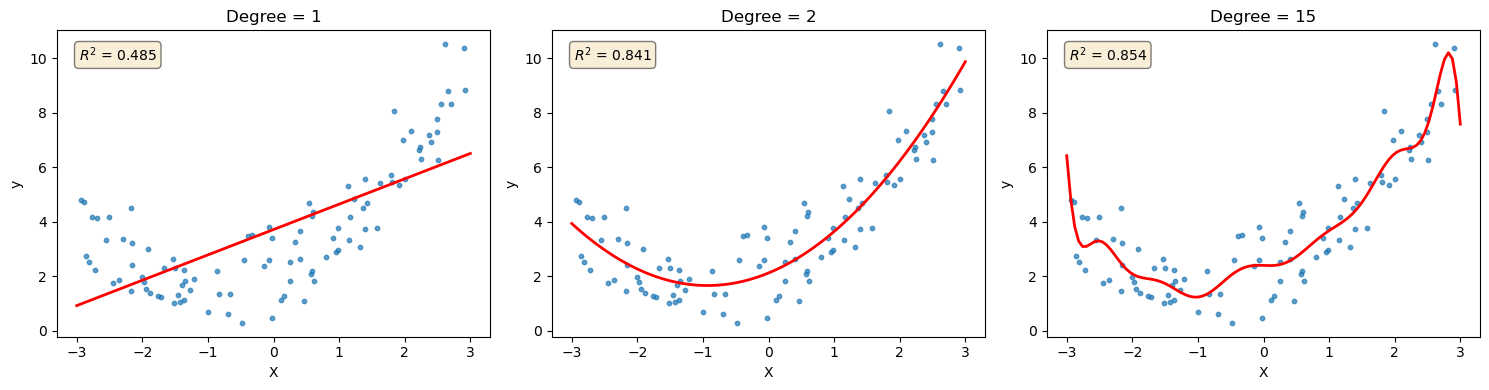

In [12]:
# 尝试不同的阶数：1（线性）， 2， 15（过高）
degrees = [1, 2, 15]
plt.figure(figsize=(15, 4))

for i, degree in enumerate(degrees):
    # 创建子图
    ax = plt.subplot(1, len(degrees), i + 1)
    
    # 生成多项式特征并训练模型
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly_features.fit_transform(X)
    lin_reg = LinearRegression()
    lin_reg.fit(X_poly, y)
    
    # 预测并绘图
    y_new = lin_reg.predict(poly_features.transform(X_new))
    
    ax.scatter(X, y, s=10, alpha=0.7)
    ax.plot(X_new, y_new, 'r-', linewidth=2)
    ax.set_title(f'Degree = {degree}')
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    # 计算并显示R²分数（越接近1越好）
    y_pred = lin_reg.predict(X_poly)
    r2 = r2_score(y, y_pred)
    ax.text(0.05, 0.95, f'$R^2$ = {r2:.3f}', transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()